<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 136.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 177.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 181.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 156.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 155.0 MB/s eta 0:00:00


#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




<Axes: title={'center': 'Rlshp between Age and JobSatPoints_6'}, xlabel='Age', ylabel='Job Satisfaction'>

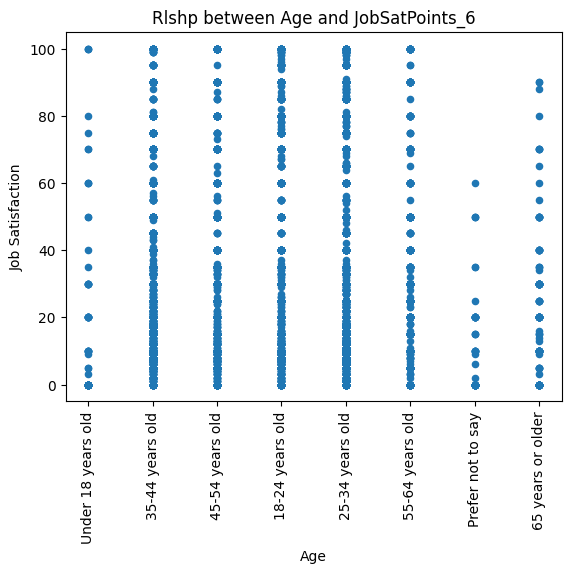

In [4]:
## Write your code here

df.plot(
    kind="scatter",
    x="Age",
    y="JobSatPoints_6",
    ylabel="Job Satisfaction",
    title="Rlshp between Age and JobSatPoints_6",
    rot=90
)


#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


<Axes: title={'center': 'Rlshp between ConvertedCompYearly and JobSatPoints_6'}, xlabel='Job Satisfaction', ylabel='ConvertedCompYearly'>

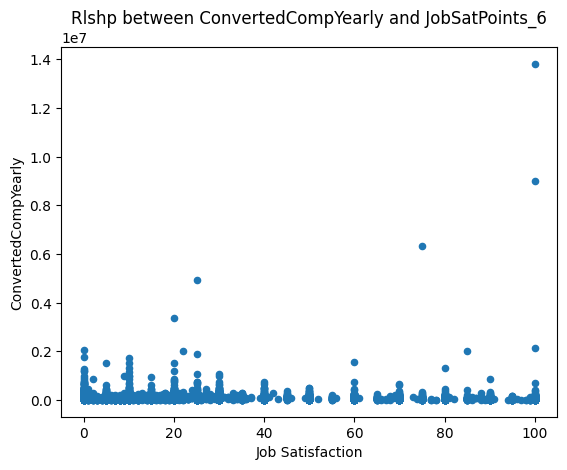

In [3]:
## Write your code here
df.plot(
    kind="scatter",
    y="ConvertedCompYearly",
    x="JobSatPoints_6",
    xlabel="Job Satisfaction",
    title="Rlshp between ConvertedCompYearly and JobSatPoints_6",
    
)


### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


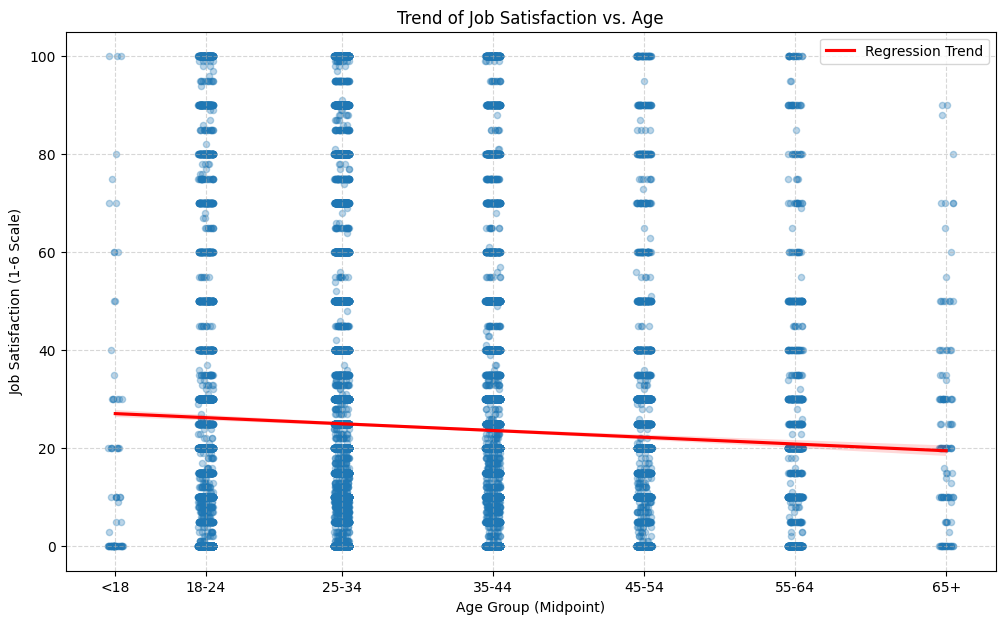

In [24]:

age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_Numeric'] = df['Age'].map(age_mapping)

#  Clean the data
df_plot = df.dropna(subset=['Age_Numeric', 'JobSatPoints_6'])

#  Create the plot
plt.figure(figsize=(12, 7))

# use regplot to add the scatter points and the regression line
# x_jitter adds a bit of spread to the discrete age values for better visibility
sns.regplot(
    data=df_plot, 
    x='Age_Numeric', 
    y='JobSatPoints_6', 
    scatter_kws={'alpha': 0.3, 's': 20}, 
    line_kws={'color': 'red', 'label': 'Regression Trend'},
    x_jitter=0.5
)

# Customizing the X-axis labels to match original categories
plt.xticks(
    ticks=[15, 21, 30, 40, 50, 60, 70], 
    labels=['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
)

plt.title('Trend of Job Satisfaction vs. Age')
plt.xlabel('Age Group (Midpoint)')
plt.ylabel('Job Satisfaction (1-6 Scale)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


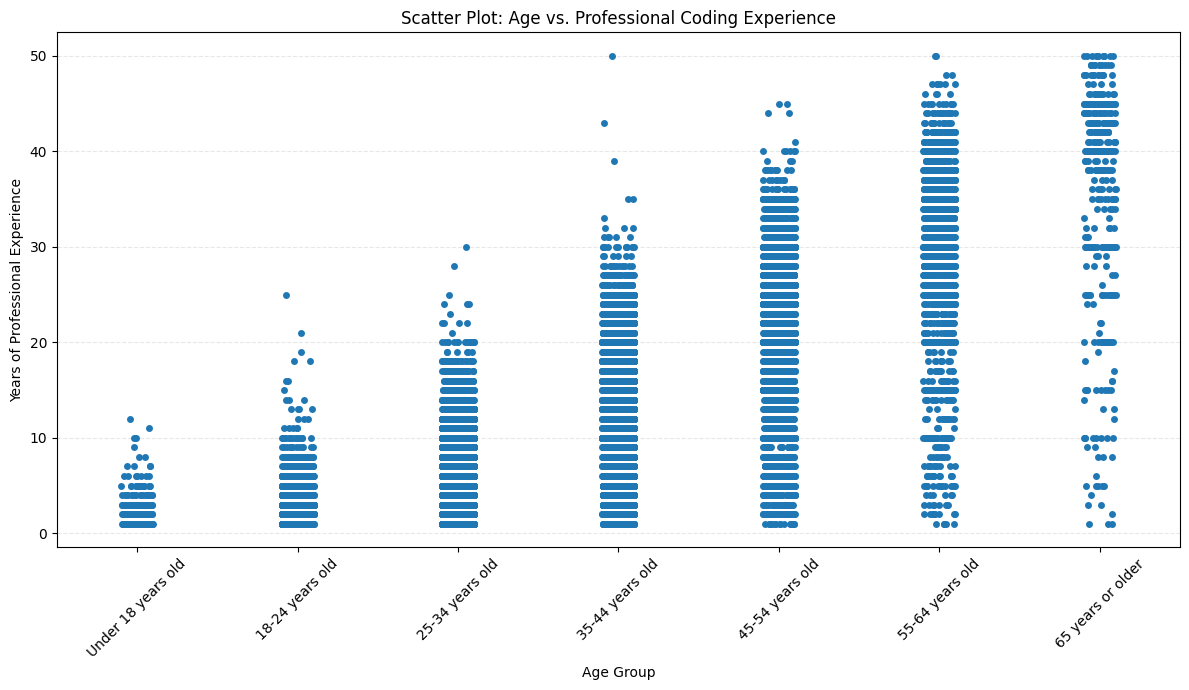

In [8]:

# Convert to numeric, replacing strings like 'Less than 1 year' with 0 and 'More than 50 years' with 50
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Define the logical order for the Age categories
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

# Filter out 'Prefer not to say' and missing values for a cleaner plot
df_plot = df[df['Age'].isin(age_order)].dropna(subset=['YearsCodePro'])

# Create the Scatter Plot
plt.figure(figsize=(12, 7))
sns.stripplot(
    data=df_plot, 
    x='Age', 
    y='YearsCodePro', 
    order=age_order, 
    
)

#  Formatting
plt.title('Scatter Plot: Age vs. Professional Coding Experience')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Experience')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


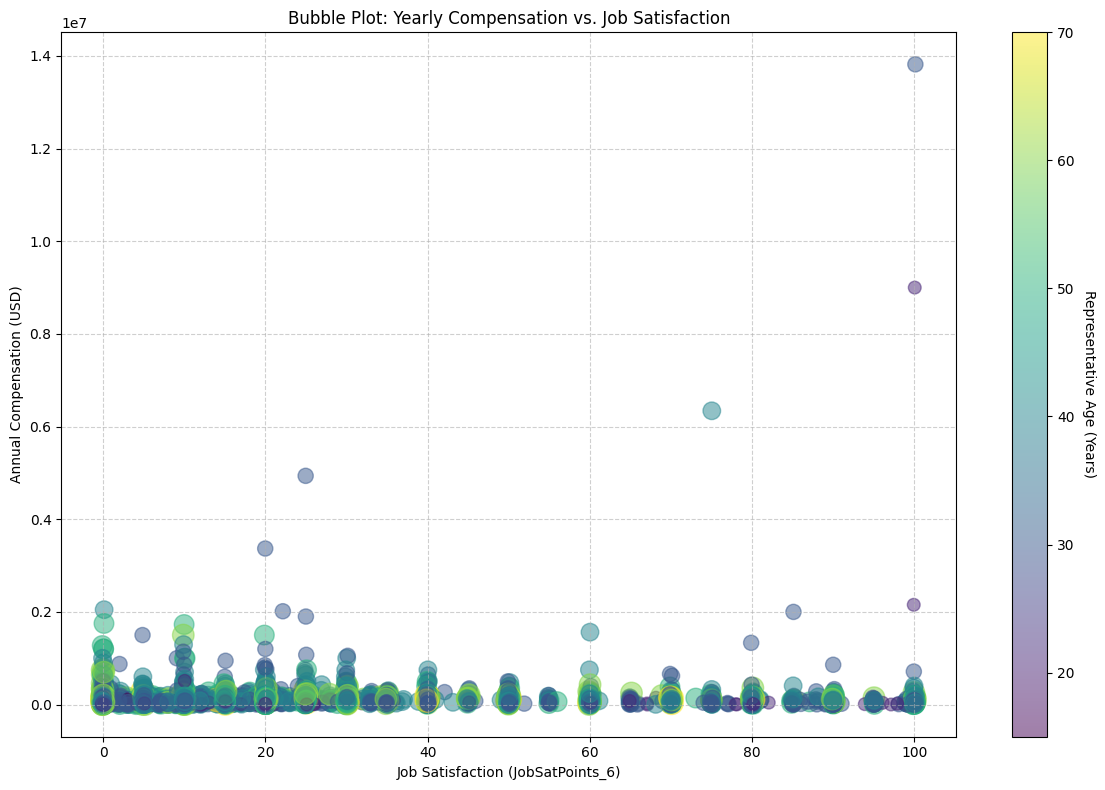

In [12]:

df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Age'])

#Numeric representatives for each range
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df_clean['Age_Numeric'] = df_clean['Age'].map(age_map)

# Create the Bubble Plot
plt.figure(figsize=(12, 8))

# Adding a small amount of jitter to JobSatPoints_6 helps visualize density
# since satisfaction scores are usually discrete integers
x_jittered = df_clean['JobSatPoints_6'] + np.random.uniform(-0.15, 0.15, size=len(df_clean))

scatter = plt.scatter(
    x=x_jittered, 
    y=df_clean['ConvertedCompYearly'],
    s=df_clean['Age_Numeric'] * 4,  # Adjust size multiplier for visibility
    alpha=0.5,
    c=df_clean['Age_Numeric'],     # Color points by age as well
)

# Formatting and Labels
plt.title('Bubble Plot: Yearly Compensation vs. Job Satisfaction')
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Annual Compensation (USD)')

# Colorbar to indicate what colors correspond to which ages
cbar = plt.colorbar(scatter)
cbar.set_label('Representative Age (Years)', rotation=270, labelpad=15)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


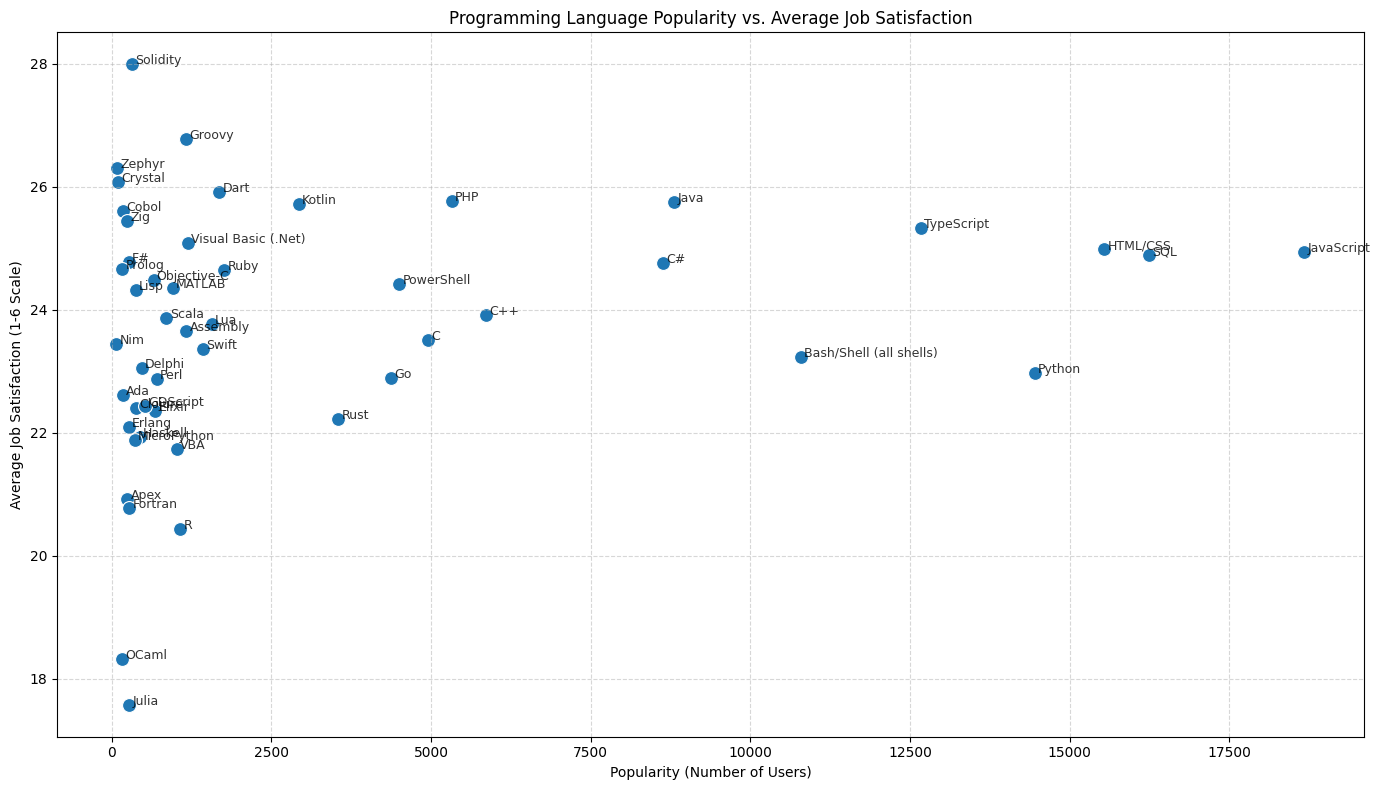

In [15]:
## Write your code here

df_clean = df.dropna(subset=['LanguageHaveWorkedWith', 'JobSatPoints_6'])

df_lang = df_clean.assign(Language=df_clean['LanguageHaveWorkedWith'].str.split(';')).explode('Language')

# Aggregate statistics per language
lang_stats = df_lang.groupby('Language').agg(
    Popularity=('Language', 'count'),
    AvgSatisfaction=('JobSatPoints_6', 'mean')
).reset_index()

# Create the Scatter Plot
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=lang_stats, 
    x='Popularity', 
    y='AvgSatisfaction', 
    s=100, 

)

# Label each point with the language name for clarity
for i in range(lang_stats.shape[0]):
    plt.text(
        x=lang_stats.Popularity[i] + 50, 
        y=lang_stats.AvgSatisfaction[i], 
        s=lang_stats.Language[i], 
        fontsize=9, 
        alpha=0.8
    )

# Formatting
plt.title('Programming Language Popularity vs. Average Job Satisfaction')
plt.xlabel('Popularity (Number of Users)')
plt.ylabel('Average Job Satisfaction (1-6 Scale)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


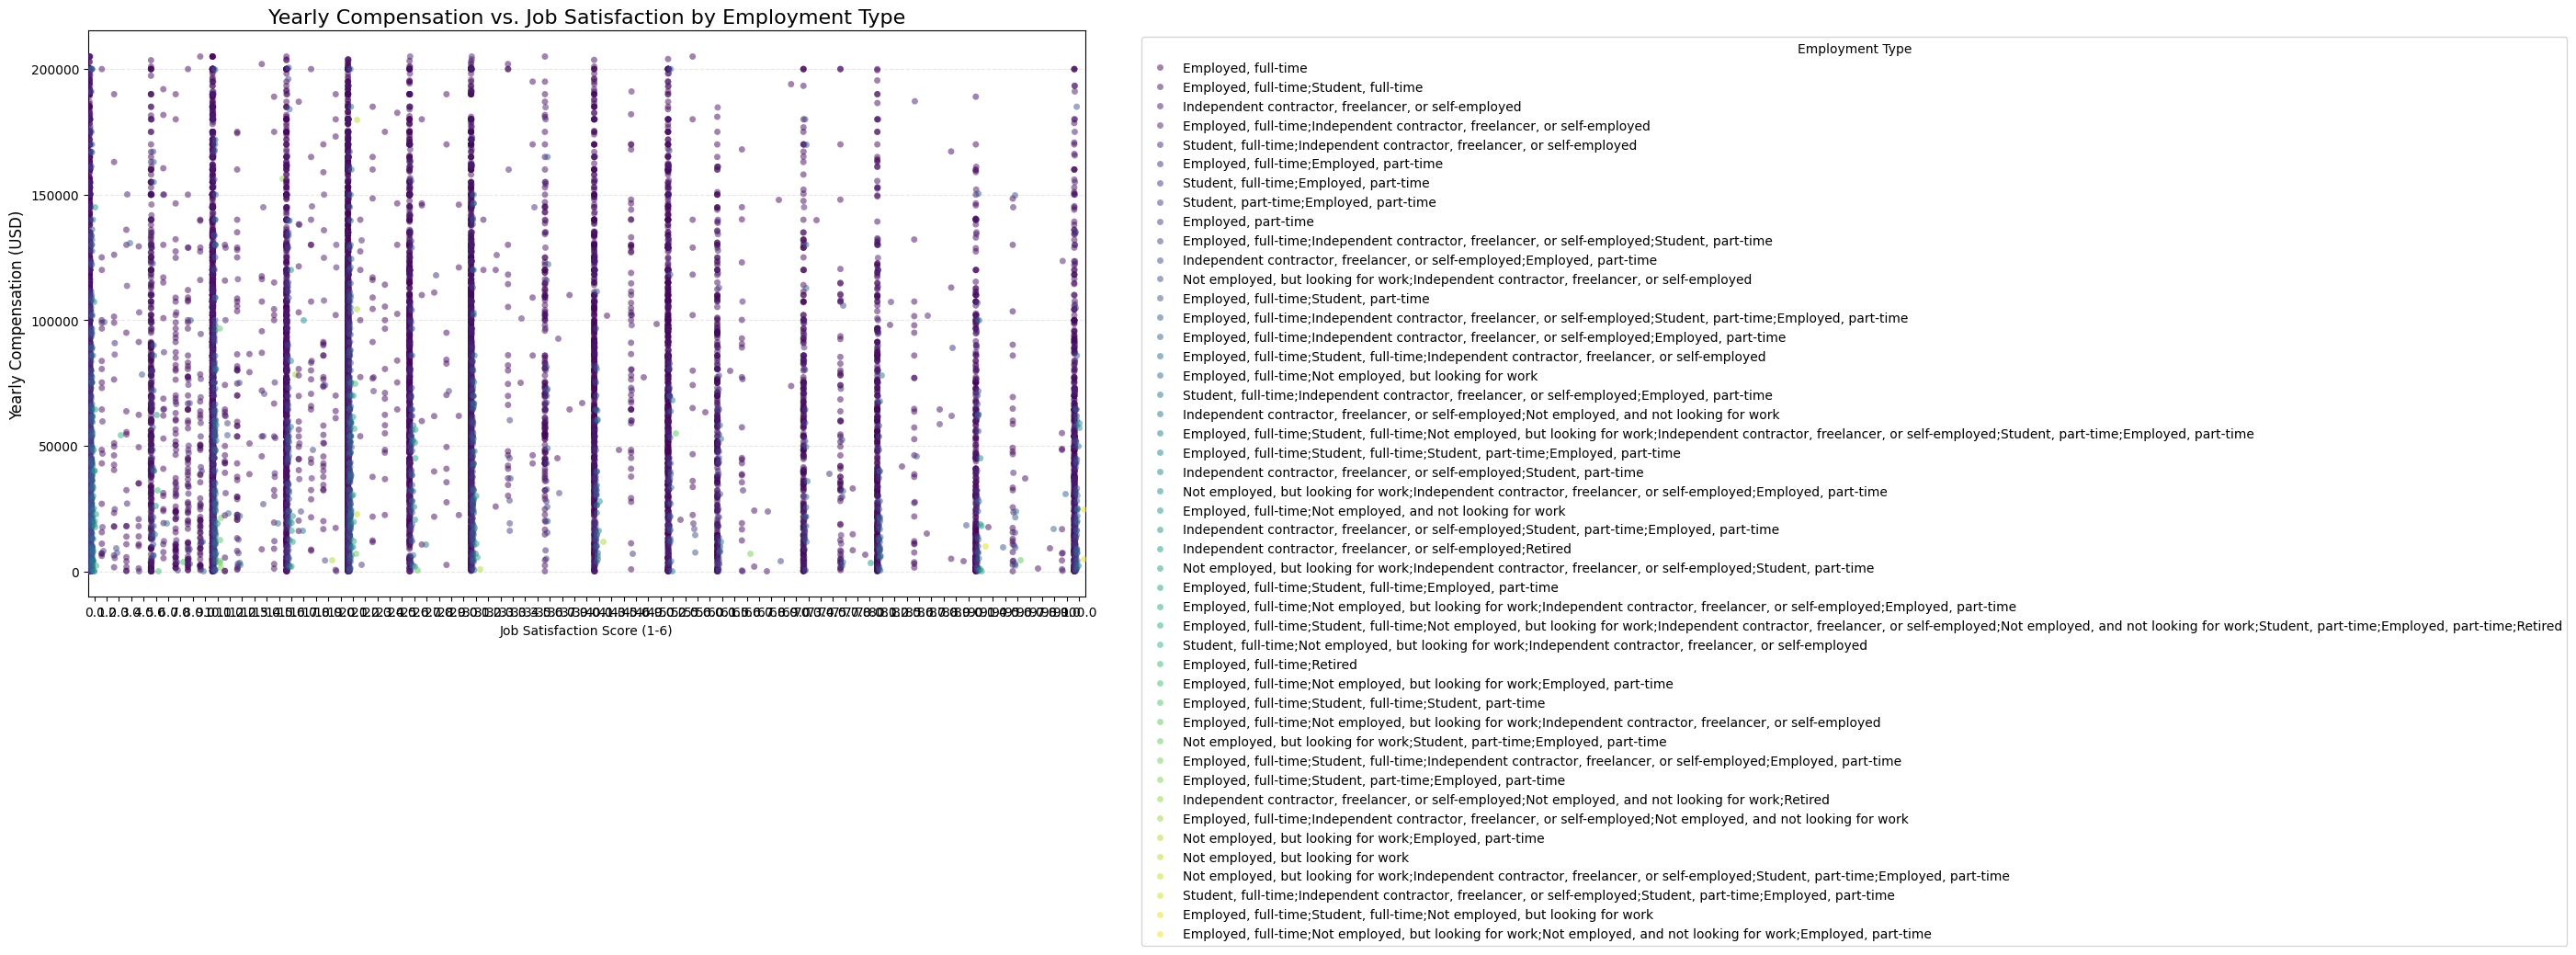

In [22]:
## Write your code here

# Filter the relevant columns and drop rows with missing values
cols = ['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']
df_clean = df[cols].dropna()

q_limit = df_clean['ConvertedCompYearly'].quantile(0.95)
df_filtered = df_clean[df_clean['ConvertedCompYearly'] <= q_limit]

# Create the Plot
plt.figure(figsize=(14, 8))

# We use sns.stripplot to handle the discrete nature of the JobSatPoints_6 axis
sns.stripplot(
    data=df_filtered, 
    x='JobSatPoints_6', 
    y='ConvertedCompYearly', 
    hue='Employment', 
    dodge=True,          # Separates the employment types horizontally for each satisfaction level
    jitter=0.25,         # Adds noise so points don't overlap perfectly
    alpha=0.5,           # Adds transparency to show point density
    palette='viridis'    # A colorblind-friendly color palette
)

# 5. Formatting
plt.title('Yearly Compensation vs. Job Satisfaction by Employment Type', fontsize=16)
plt.xlabel('Job Satisfaction Score (1-6)')
plt.ylabel('Yearly Compensation (USD)', fontsize=12)

# Place the legend outside the plot area
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


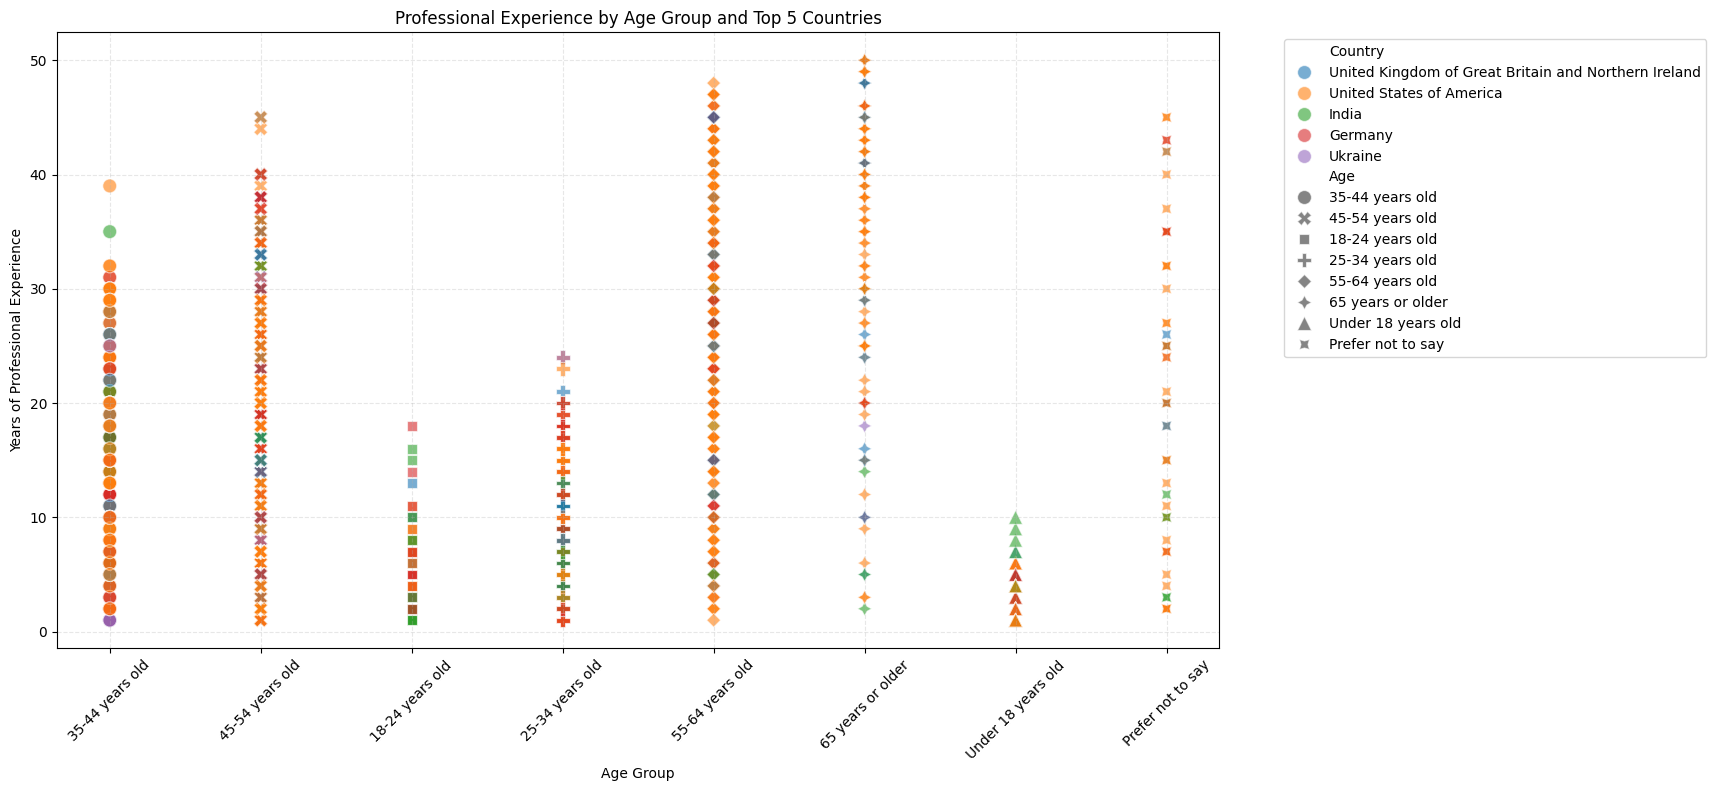

In [23]:

#  Prepare the data
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df_clean = df.dropna(subset=['YearsCodePro', 'Age', 'Country'])

# Focus on Top 5 countries to avoid cluttering the plot
top_countries = df_clean['Country'].value_counts().nlargest(5).index
df_subset = df_clean[df_clean['Country'].isin(top_countries)]

# Create the Visualization
plt.figure(figsize=(15, 8))

# We use hue for Country and style for Age to distinguish categories
sns.scatterplot(
    data=df_subset,
    x='Age',
    y='YearsCodePro',
    hue='Country',
    style='Age',
    alpha=0.6,
    s=100
)

#  Formatting
plt.title('Professional Experience by Age Group and Top 5 Countries')
plt.xlabel('Age Group')
plt.ylabel('Years of Professional Experience')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
